<a href="https://colab.research.google.com/github/keerthikabheemaraj/customer_sales_board/blob/main/mini_project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from google.colab import files
uploaded = files.upload()
import os
os.listdir()

Saving Sample - Superstore.csv.zip to Sample - Superstore.csv (2).zip


['.config',
 'Sample - Superstore.csv (2).zip',
 'Sample - Superstore.csv (1).zip',
 'Sample - Superstore.csv',
 'Sample - Superstore.csv.zip',
 'sample_data']

In [12]:
import zipfile
with zipfile.ZipFile("Sample - Superstore.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()
print("ZIP file extracted successfully!")
import os
os.listdir()

ZIP file extracted successfully!


['.config',
 'Sample - Superstore.csv (2).zip',
 'Sample - Superstore.csv (1).zip',
 'Sample - Superstore.csv',
 'Sample - Superstore.csv.zip',
 'sample_data']

In [14]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [16]:
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [28]:
print("sales:",df['Sales'].sum())
print("profit:",df['Profit'].sum())
print("order:",df['Order ID'].nunique())

sales: 2297200.8603000003
profit: 286397.0217
order: 5009


In [18]:
monthly_sales = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

2297200.8603000003


In [29]:
top_customers = df.groupby(
    'Customer Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

In [30]:
customer_profit = df.groupby(
    'Customer Name'
)['Profit'].sum().sort_values(
    ascending=False
).head(10)

In [31]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


<Axes: xlabel='Order Date'>

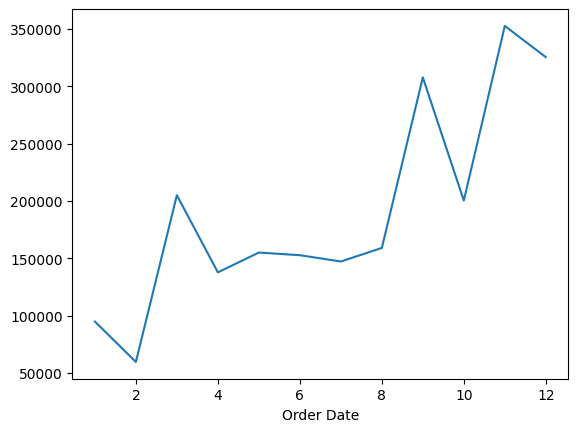

In [32]:
monthly_sales.plot(kind='line')

<Axes: xlabel='Category', ylabel='Sales'>

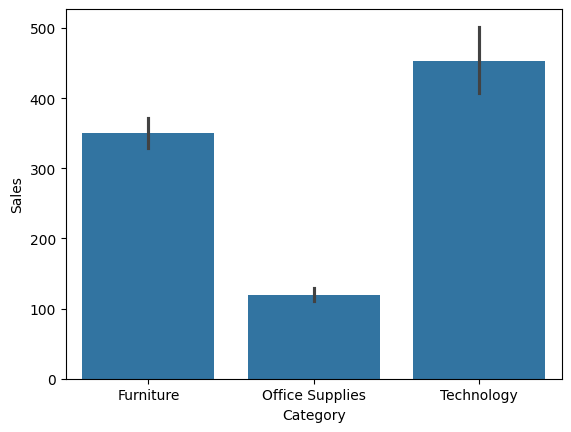

In [33]:
sns.barplot(
    x='Category',
    y='Sales',
    data=df
)

<Axes: xlabel='Region', ylabel='Profit'>

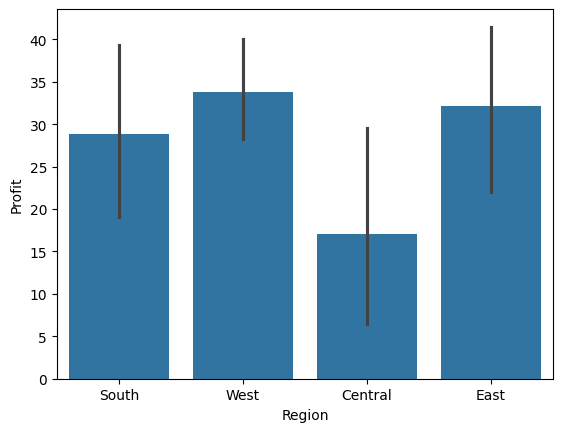

In [34]:
sns.barplot(
    x='Region',
    y='Profit',
    data=df
)

<Axes: xlabel='Customer Name'>

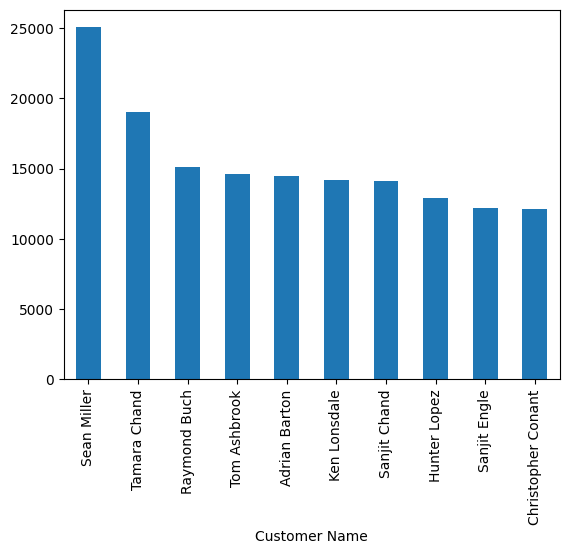

In [35]:
top_customers.plot(kind='bar')

<Axes: ylabel='count'>

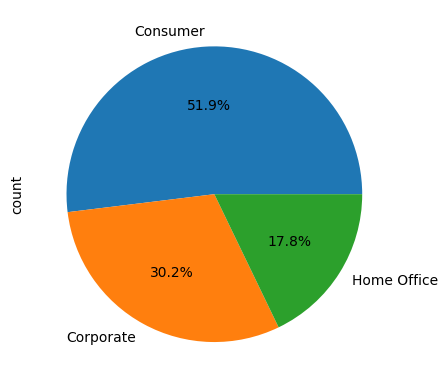

In [36]:
df['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)